# explorative data analysis

In [2]:
# import modules 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
pd.set_option('display.float_format', '{:.2f}'.format)
from pathlib import Path



In [3]:
# load dataset

df = pd.read_csv(
    "C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/03_features/conversation_features.csv"
)

print(df.shape)
# df.head()


(57529, 30)


In [4]:
df.describe()

,first_prompt_tokens,first_response_tokens,total_turns,interaction_rounds,total_user_tokens,total_assistant_tokens,total_tokens,log_total_tokens,follow_up_prompts,needs_follow_up,...,question_count,orthographic_error_rate,topic,topic_prob,embedding_novelty,topic_confidence,is_generic_topic,topic_size,topic_size_log,target_cost
count,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,...,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00
mean,176.59,496.31,16.62,8.31,737.40,4090.66,4828.05,7.52,7.33,0.73,...,0.60,0.05,0.43,0.56,0.76,0.56,0.40,24647.12,9.77,496.31
std,802.25,903.69,36.51,18.25,3076.31,10372.56,11669.88,1.35,18.43,0.44,...,2.96,0.07,4.37,0.31,0.14,0.31,0.49,8167.03,1.41,903.69
min,2.00,1.00,2.00,1.00,5.00,1.00,9.00,2.30,0.00,0.00,...,0.00,0.00,-1.00,0.00,0.37,0.00,0.00,51.00,3.95,1.00
25%,16.00,155.00,2.00,1.00,47.00,542.00,698.00,6.55,0.00,0.00,...,0.00,0.00,-1.00,0.30,0.66,0.30,0.00,22662.00,10.03,155.00
50%,34.00,329.00,6.00,3.00,142.00,1418.00,1763.00,7.48,2.00,1.00,...,0.00,0.02,-1.00,0.56,0.76,0.56,0.00,30054.00,10.31,329.00
75%,112.00,587.00,16.00,8.00,473.00,3762.00,4537.00,8.42,7.00,1.00,...,1.00,0.08,0.00,0.80,0.87,0.80,1.00,30054.00,10.31,587.00
max,79821.00,76828.00,972.00,486.00,168177.00,358980.00,360095.00,12.79,547.00,1.00,...,261.00,1.00,35.00,1.00,1.18,1.00,1.00,30054.00,10.31,76828.00


<Axes: >

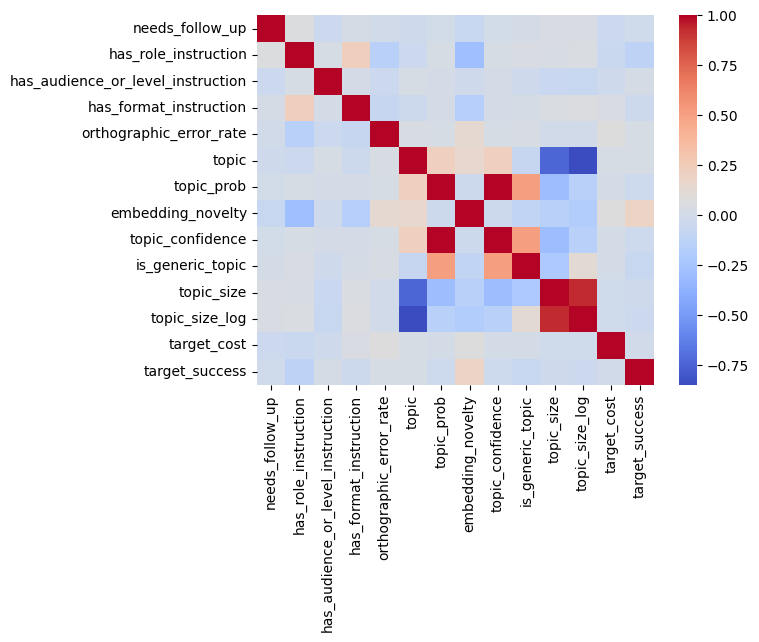

In [5]:
# correlations

sns.heatmap(df[['needs_follow_up', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
        'orthographic_error_rate', 'topic', 'topic_prob',
       'embedding_novelty', 'topic_confidence', 'is_generic_topic',
       'topic_size', 'topic_size_log', 'target_cost', 'target_success']].corr(), cmap="coolwarm")

In [6]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'follow_up_prompts',
       'needs_follow_up', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'topic', 'topic_prob', 'topic_label',
       'embedding_novelty', 'topic_confidence', 'is_generic_topic',
       'topic_size', 'topic_size_log', 'target_cost', 'target_success'],
      dtype='str')

# features

### structure features

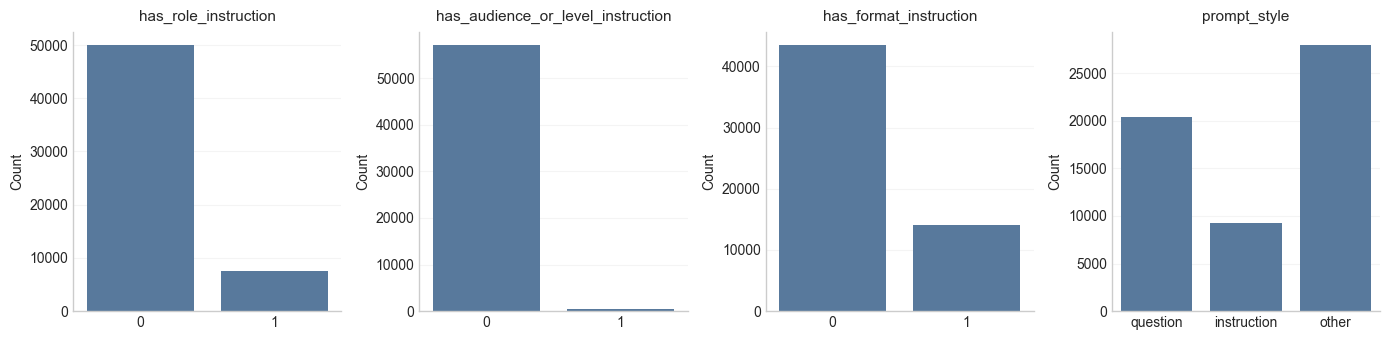

In [7]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes = axes.flatten()

prompt_design_features = [
    'has_role_instruction',
    'has_audience_or_level_instruction',
    'has_format_instruction',
    'prompt_style'
]

for i, feature in enumerate(prompt_design_features):
    sns.countplot(
        data=df,
        x=feature,
        ax=axes[i],
        color="#4C78A8"
    )

    axes[i].set_title(feature, fontsize=11, pad=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

    axes[i].grid(axis="y", alpha=0.2)
    axes[i].grid(axis="x", visible=False)

    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()


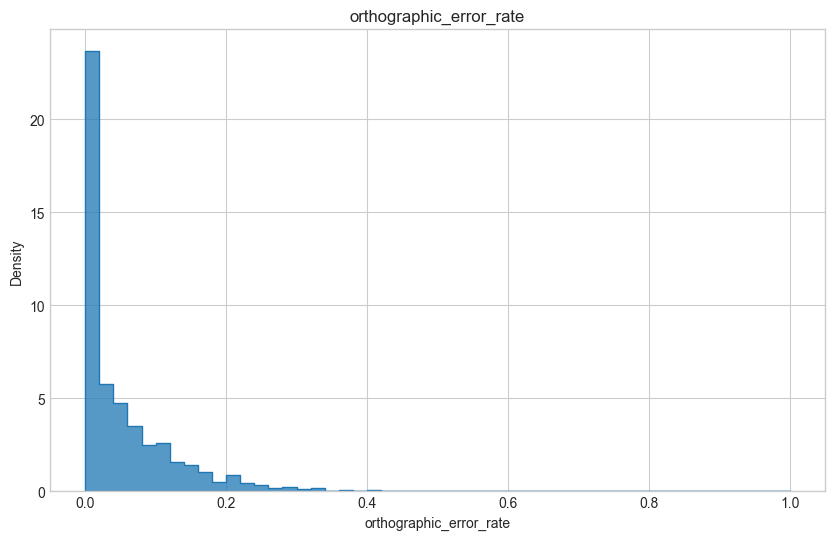

In [8]:
plot_data = df[['orthographic_error_rate']]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="orthographic_error_rate",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title('orthographic_error_rate')
plt.xlabel('orthographic_error_rate')
plt.ylabel("Density")

plt.show()

In [9]:
OER = 0.40

outliers_oer = df[df["orthographic_error_rate"] > OER]   

# print

pd.set_option("display.max_rows", None)

#print(outliers_oer)    # n=247

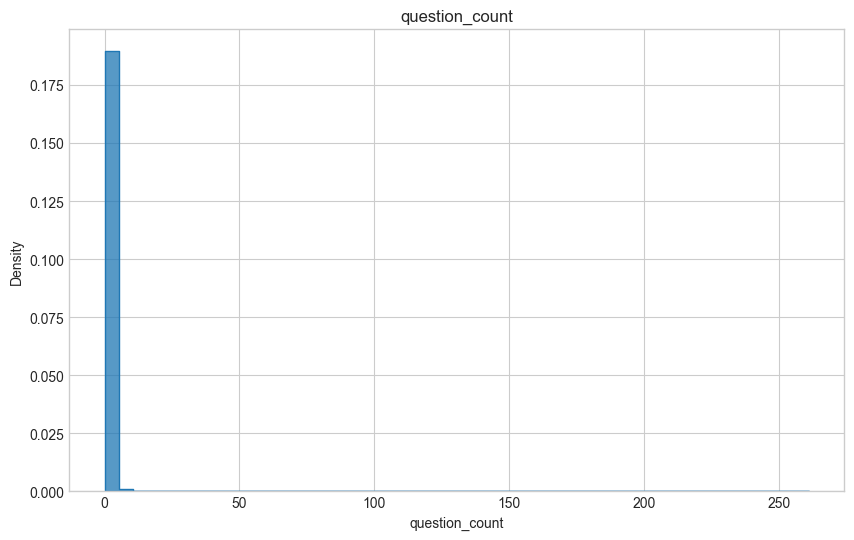

In [10]:
plot_data = df[['question_count']]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="question_count",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title('question_count')
plt.xlabel('question_count')
plt.ylabel("Density")

plt.show()

In [11]:
QC=50

outliers_QC = df[df["question_count"] > QC]   

# print

pd.set_option("display.max_rows", None)

#print(outliers_QC)    # question_count should not be a feature, as sometimes prompts ask for transcription or translation, etc.

### topic and task features

In [12]:
# prompt_style

prompt_style_summary = df.groupby("prompt_style").agg(
    conversations=("conversation_id", "count"),
    median_first_prompts_token=("first_prompt_tokens", "median"),
    median_first_response_tokens=("first_response_tokens", "median"),
    median_target_cost=("target_cost", "median"),
    mean_target_success=("target_success", "mean"),
    mean_role_instruction=("has_role_instruction", "mean"),
    mean_audience_instruction=("has_audience_or_level_instruction", "mean"),
    mean_format_instruction=("has_format_instruction", "mean"),
    mean_question_count=("question_count", "mean"),
    mean_orthographic_error_rate=("orthographic_error_rate", "mean")
).sort_values("conversations", ascending=False)


prompt_style_summary

,conversations,median_first_prompts_token,median_first_response_tokens,median_target_cost,mean_target_success,mean_role_instruction,mean_audience_instruction,mean_format_instruction,mean_question_count,mean_orthographic_error_rate
prompt_style,,,,,,,,,,
other,27917,43.00,342.00,342.00,0.85,0.19,0.01,0.27,0.00,0.05
question,20381,32.00,282.00,282.00,0.87,0.11,0.00,0.23,1.68,0.05
instruction,9231,22.00,412.00,412.00,0.86,0.02,0.03,0.20,0.00,0.05


In [13]:
# task_type

task_type_summary = df.groupby("task_type").agg(
    conversations=("conversation_id", "count"),
    median_first_prompts_token=("first_prompt_tokens", "median"),
    median_first_response_tokens=("first_response_tokens", "median"),
    median_target_cost=("target_cost", "median"),
    mean_target_success=("target_success", "mean"),
    mean_role_instruction=("has_role_instruction", "mean"),
    mean_audience_instruction=("has_audience_or_level_instruction", "mean"),
    mean_format_instruction=("has_format_instruction", "mean"),
    mean_question_count=("question_count", "mean"),
    mean_orthographic_error_rate=("orthographic_error_rate", "mean")
).sort_values("conversations", ascending=False)


task_type_summary


,conversations,median_first_prompts_token,median_first_response_tokens,median_target_cost,mean_target_success,mean_role_instruction,mean_audience_instruction,mean_format_instruction,mean_question_count,mean_orthographic_error_rate
task_type,,,,,,,,,,
general_assistance,23355,21.00,289.00,289.00,0.88,0.05,0.00,0.16,0.48,0.06
writing_generation,10732,41.50,379.00,379.00,0.81,0.13,0.00,0.24,0.30,0.04
coding,10030,85.00,574.00,574.00,0.87,0.16,0.01,0.39,0.88,0.07
explanation,5534,23.00,256.00,256.00,0.92,0.12,0.06,0.21,1.06,0.04
brainstorming,2264,61.00,327.50,327.50,0.87,0.24,0.00,0.30,0.49,0.03
email_writing,1650,255.00,321.00,321.00,0.83,0.22,0.00,0.41,1.00,0.05
translation,1500,65.00,363.50,363.50,0.81,0.26,0.01,0.34,0.56,0.03
summarization,1340,205.00,211.00,211.00,0.89,0.30,0.01,0.49,0.94,0.04
roleplay,1124,61.00,192.00,192.00,0.71,0.86,0.00,0.22,0.25,0.03


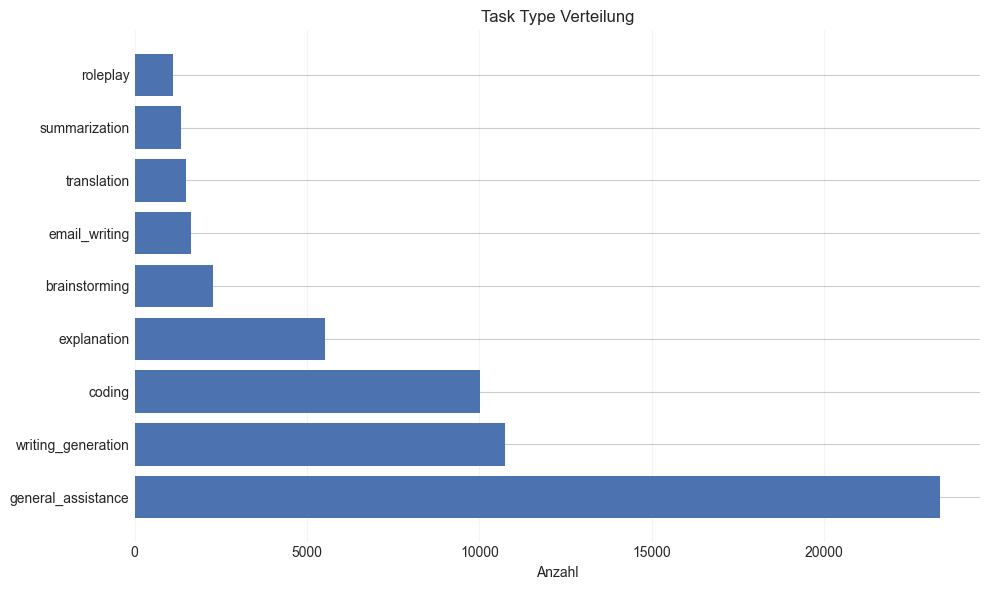

In [14]:
counts = (
    df["task_type"]
    .value_counts()
    .sort_values(ascending=True)  # oder False für Top oben
)

plt.figure(figsize=(10, 6))

plt.barh(counts.index, counts.values, color="#4C72B0")

plt.title("Task Type Verteilung")
plt.xlabel("Anzahl")

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.2)

plt.box(False)
plt.tight_layout()
plt.show()

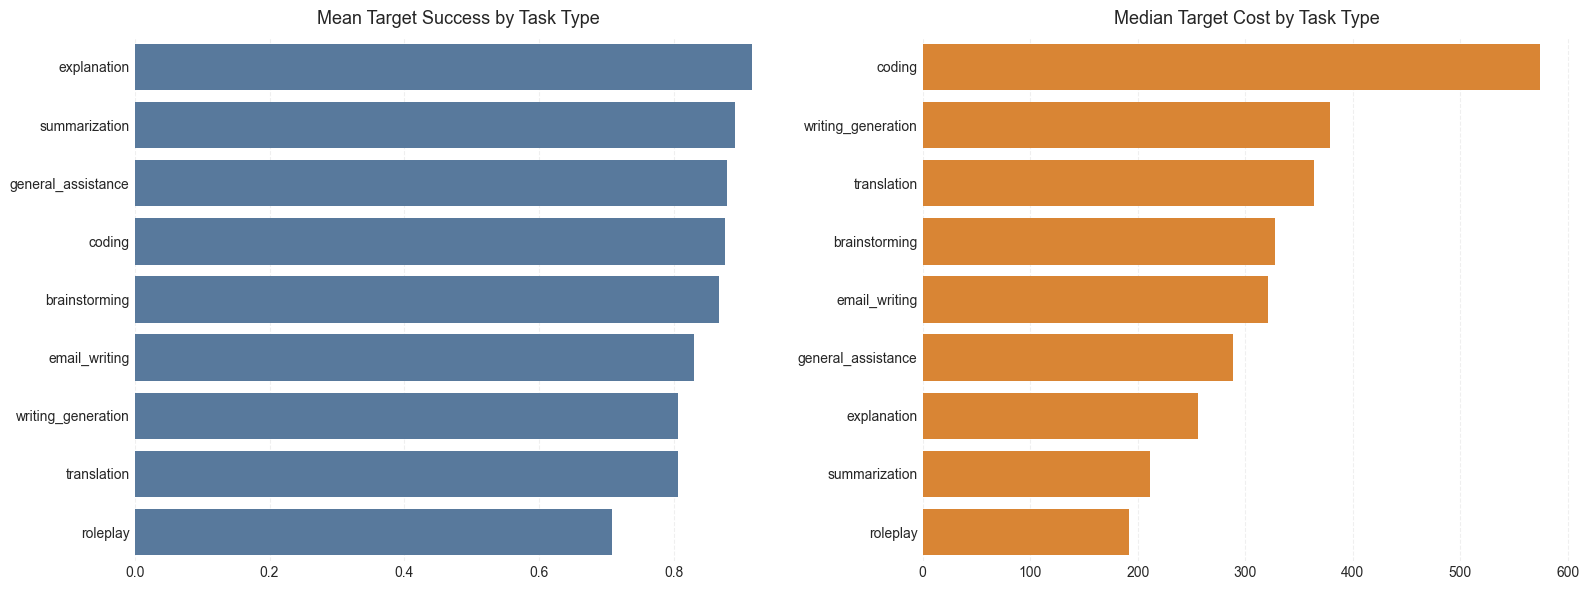

In [15]:
plt.style.use("seaborn-v0_8-whitegrid")

plot_df = task_type_summary.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Mean Target Success ---
sns.barplot(
    data=plot_df.sort_values("mean_target_success", ascending=False),
    x="mean_target_success",
    y="task_type",
    ax=axes[0],
    color="#4C78A8"
)

axes[0].set_title("Mean Target Success by Task Type", fontsize=13, pad=10)
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].grid(axis="x", linestyle="--", alpha=0.3)
axes[0].grid(axis="y", visible=False)

# --- Plot 2: Median Target Cost ---
sns.barplot(
    data=plot_df.sort_values("median_target_cost", ascending=False),
    x="median_target_cost",
    y="task_type",
    ax=axes[1],
    color="#F58518"
)

axes[1].set_title("Median Target Cost by Task Type", fontsize=13, pad=10)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].grid(axis="x", linestyle="--", alpha=0.3)
axes[1].grid(axis="y", visible=False)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [16]:
df[["topic_label", "topic"]].value_counts()

topic_label                             topic
-1_like_use_data_write                  -1       30054
0_write_chatgpt_use_data                 0       22662
1_trip_visit_travel_day                  1         589
2_000_minutes_total_did                  2         431
3_recipe_chicken_add_ingredients         3         337
4_git_github_commit_branch               4         262
5_patient_mg_blood_ct                    5         219
6_mathematical_equation_math_2x          6         204
7_1i_1can_1what_help                     7         187
8_quantum_computing_simple terms_terms   8         187
9_excel_sheet_column_cell                9         179
10_string_regex_substitute_strings       10        146
11_36_goal_15_france                     11        132
12_docker_container_feature_compose      12        131
13_extension_browser_tab_js              13        125
14_exercise_week_fitness_weight          14        120
15_golang_logger_log_file                15        109
16_gpt_gt_include_p

In [17]:
# topic features
#'topic', 'topic_prob', 'topic_label', 'embedding_novelty', 'topic_confidence', 'is_generic_topic', 'topic_size', 'topic_size_log'

topic_labels_given = {
    -1: "Outlier / Noise",
     0: "ChatGPT / Writing / Data Usage",
     1: "Travel / Trips",
     2: "Time / Duration Tracking",
     3: "Cooking / Recipes",
     4: "Git / GitHub Development",
     5: "Medical / Clinical Data",
     6: "Math / Equations",
}

df["topic_name"] = df["topic"].map(topic_labels_given)

# topic_label

topic_label_1_summary = df.groupby("topic_name").agg(
    conversations=("conversation_id", "count"),
    median_first_prompts_token=("first_prompt_tokens", "median"),
    median_first_response_tokens=("first_response_tokens", "median"),
    median_target_cost=("target_cost", "median"),
    mean_target_success=("target_success", "mean"),
    mean_role_instruction=("has_role_instruction", "mean"),
    mean_audience_instruction=("has_audience_or_level_instruction", "mean"),
    mean_format_instruction=("has_format_instruction", "mean"),
    mean_question_count=("question_count", "mean"),
    mean_orthographic_error_rate=("orthographic_error_rate", "mean")
).sort_values("conversations", ascending=False)


topic_label_1_summary.head(10)


,conversations,median_first_prompts_token,median_first_response_tokens,median_target_cost,mean_target_success,mean_role_instruction,mean_audience_instruction,mean_format_instruction,mean_question_count,mean_orthographic_error_rate
topic_name,,,,,,,,,,
Outlier / Noise,30054,33.00,329.00,329.00,0.87,0.13,0.01,0.25,0.61,0.05
ChatGPT / Writing / Data Usage,22662,36.00,329.00,329.00,0.83,0.15,0.01,0.26,0.55,0.06
Travel / Trips,589,38.00,391.00,391.00,0.93,0.16,0.00,0.19,0.39,0.03
Time / Duration Tracking,431,51.00,153.00,153.00,0.92,0.02,0.00,0.07,0.94,0.01
Cooking / Recipes,337,25.00,374.00,374.00,0.90,0.14,0.00,0.23,0.34,0.03
Git / GitHub Development,262,23.00,540.50,540.50,0.93,0.02,0.00,0.16,0.62,0.09
Medical / Clinical Data,219,43.00,253.00,253.00,0.95,0.12,0.00,0.16,0.83,0.05
Math / Equations,204,25.50,252.00,252.00,0.88,0.05,0.00,0.05,0.52,0.02


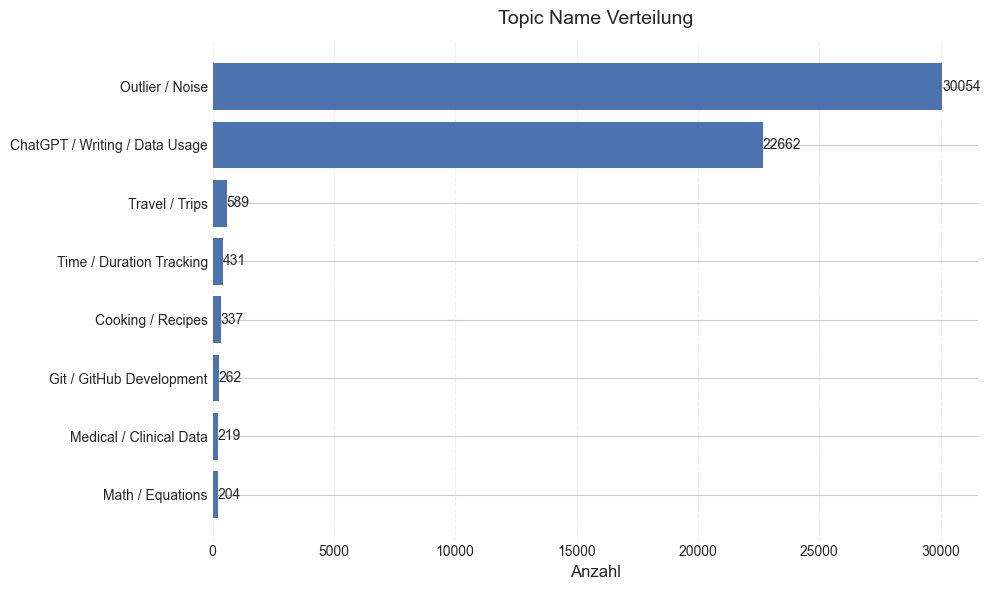

In [18]:
counts = df["topic_name"].value_counts()

plt.figure(figsize=(10, 6))

bars = plt.barh(counts.index, counts.values, color="#4C72B0")

plt.title("Topic Name Verteilung", fontsize=14, pad=12)
plt.xlabel("Anzahl", fontsize=12)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             str(int(width)),
             va="center", fontsize=10)

plt.gca().invert_yaxis() 
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.box(False)
plt.tight_layout()
plt.show()

In [19]:
# topic_label

topic_label_2_summary = df.groupby("topic_name").agg(
    conversations=("conversation_id", "count"),
    mean_novelty=("embedding_novelty", "mean"), 
    mean_confidence=("topic_confidence", "mean"),
    mean_generic=("is_generic_topic", "mean"),
    mean_topic_size=("topic_size", "mean")
).sort_values("conversations", ascending=False)


topic_label_2_summary.head(10)

,conversations,mean_novelty,mean_confidence,mean_generic,mean_topic_size
topic_name,,,,,
Outlier / Noise,30054,0.76,0.40,0.00,30054.00
ChatGPT / Writing / Data Usage,22662,0.74,0.75,1.00,22662.00
Travel / Trips,589,0.80,0.36,0.00,589.00
Time / Duration Tracking,431,0.87,0.31,0.00,431.00
Cooking / Recipes,337,0.82,0.56,0.00,337.00
Git / GitHub Development,262,0.91,0.42,0.00,262.00
Medical / Clinical Data,219,0.94,0.54,0.00,219.00
Math / Equations,204,0.85,0.62,0.00,204.00


In [20]:
df["target_success"].value_counts()

target_success
True     49529
False     8000
Name: count, dtype: int64

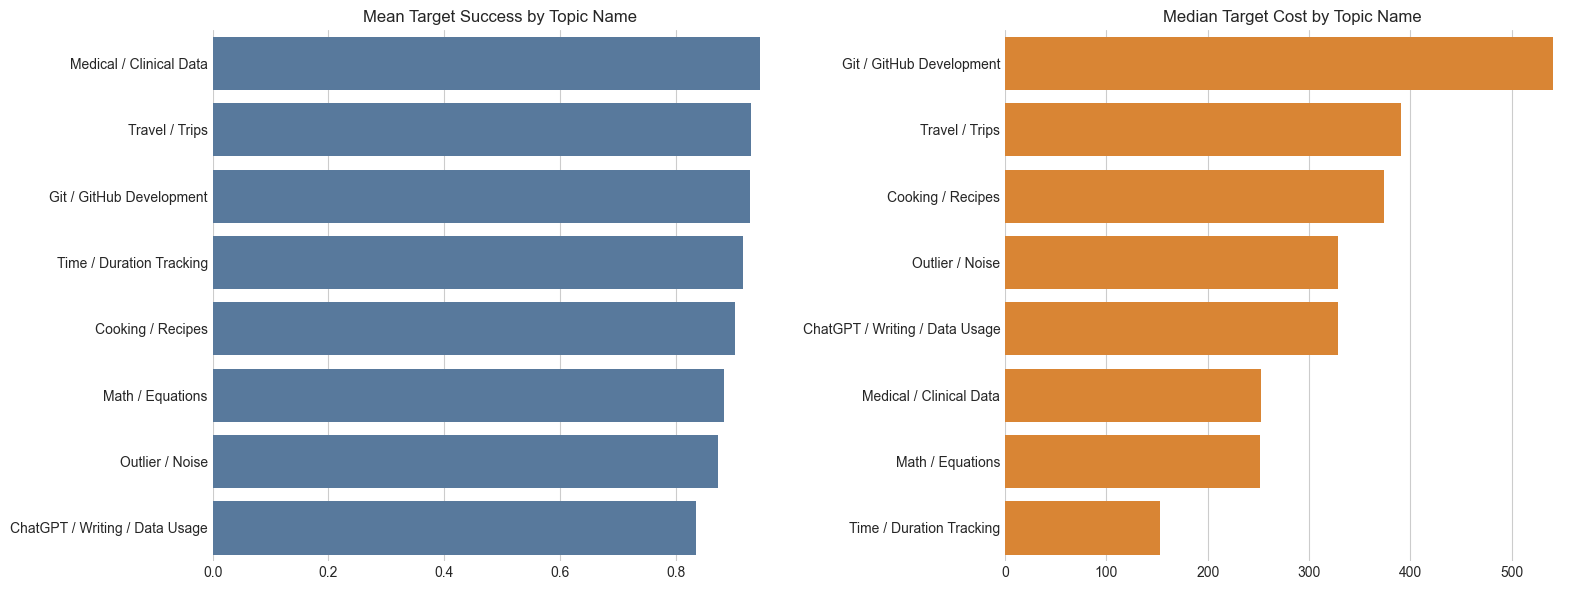

In [21]:
plot_df = topic_label_1_summary.reset_index()

# > 200 conversations
plot_df = plot_df[plot_df["conversations"] >= 200]

#plot_df = topic_label_summary.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=plot_df.sort_values("mean_target_success", ascending=False),
    x="mean_target_success",
    y="topic_name",
    ax=axes[0],
    color="#4C78A8"
)

axes[0].set_title("Mean Target Success by Topic Name")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.barplot(
    data=plot_df.sort_values("median_target_cost", ascending=False),
    x="median_target_cost",
    y="topic_name",
    ax=axes[1],
    color="#F58518"
)

axes[1].set_title("Median Target Cost by Topic Name")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [22]:
pd.crosstab(df["topic_name"], df["task_type"])

task_type,brainstorming,coding,email_writing,explanation,general_assistance,roleplay,summarization,translation,writing_generation
topic_name,,,,,,,,,
ChatGPT / Writing / Data Usage,910,4498,744,1938,8453,440,616,700,4363
Cooking / Recipes,32,9,1,21,227,3,0,6,38
Git / GitHub Development,1,72,3,17,131,0,1,1,36
Math / Equations,3,2,2,61,121,2,0,0,13
Medical / Clinical Data,10,15,0,37,110,10,3,4,30
Outlier / Noise,1125,4862,863,2950,12447,614,687,736,5770
Time / Duration Tracking,2,3,0,59,350,0,0,6,11
Travel / Trips,127,17,7,27,315,15,4,6,71


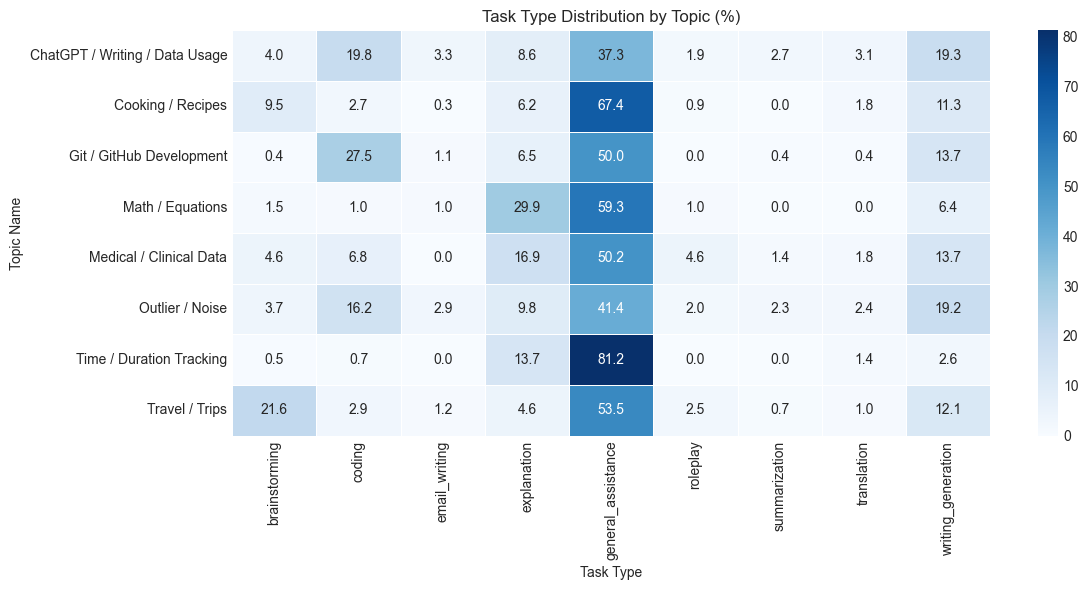

In [23]:
ct = pd.crosstab(df["topic_name"], df["task_type"])

ct_norm = ct.div(ct.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 6))

sns.heatmap(
   ct_norm,
    cmap="Blues",
    linewidths=0.5,
    annot=True,
    fmt=".1f"
)

plt.title("Task Type Distribution by Topic (%)")
plt.xlabel("Task Type")
plt.ylabel("Topic Name")

plt.tight_layout()
plt.show()

In [24]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'follow_up_prompts',
       'needs_follow_up', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'topic', 'topic_prob', 'topic_label',
       'embedding_novelty', 'topic_confidence', 'is_generic_topic',
       'topic_size', 'topic_size_log', 'target_cost', 'target_success',
       'topic_name'],
      dtype='str')

In [25]:
K = 4  # numbers of example

top_examples = (
    df.sort_values("topic_prob", ascending=False)
      .groupby("topic")
      .head(K)[["topic", "topic_prob", "first_prompt"]]
)

top_examples

for topic, sub in top_examples.groupby("topic"):
    print("\n" + "="*80)
    print(f"TOPIC: {topic}")
    print("="*80)
    
    for _, row in sub.iterrows():
        print(f"[{row['topic_prob']:.2f}] {row['first_prompt']}")


TOPIC: -1
[0.89] Turn this into competency based questions for a Customer Success Executive role:

"To be successful in this Customer Success Executive role, you should have experience working within a high-touch SaaS Customer Success team environment (i.e., hands-on, providing proactive account management), preferably in a Business-to-Business capacity. This likely includes regular customer meetings, help centre tickets (we use Zendesk), creation of ‘How to’ guides or advice etc but we’re keen to hear about any similar experiences.


You should be a great relationship builder with well-developed customer service skills (potentially gained in an account management, client management, customer success, operational or project management environment) and the ability to handle multiple concurrent projects, prioritise your own work, and remain effective during periods of increased workload.


Additionally, you will:

•	Thrive when you’re working in a methodical and analytical manner, using

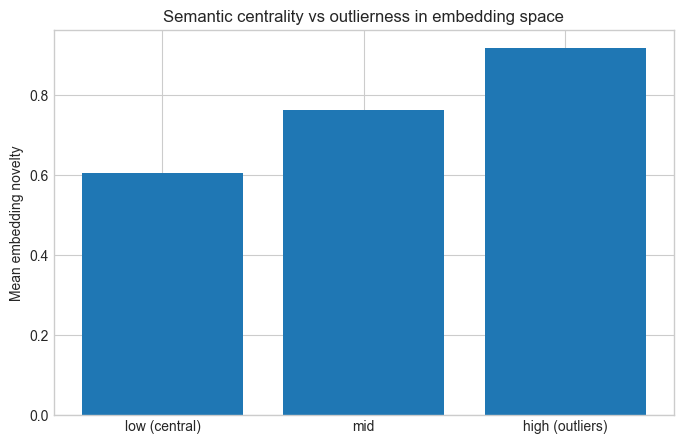

,conversation_id,first_prompt,first_response,first_prompt_tokens,first_response_tokens,total_turns,interaction_rounds,total_user_tokens,total_assistant_tokens,total_tokens,...,topic_label,embedding_novelty,topic_confidence,is_generic_topic,topic_size,topic_size_log,target_cost,target_success,topic_name,novelty_bucket
11538,c9ZSGCY,5 / 5Response format described in header:\nHEA...,<div><p>I'll provide some significant formulas...,288,1759,6,3.00,294,4778,5072,...,-1_like_use_data_write,0.55,0.08,0,30054,10.31,1759,True,Outlier / Noise,low (central)
19478,ijEPzZu,\nI will describe a Nextjs project for you by ...,"<div><p>Alright, please go ahead and describe ...",19,32,15,7.50,6871,5003,11874,...,0_write_chatgpt_use_data,0.57,0.38,1,22662,10.03,32,True,ChatGPT / Writing / Data Usage,low (central)
10064,CYcAuWq,You are a pregnancy health &amp; nutrition exp...,"<div><p>Yes, I understand your request. You wa...",218,103,28,14.00,982,6159,7141,...,0_write_chatgpt_use_data,0.55,0.81,1,22662,10.03,103,True,ChatGPT / Writing / Data Usage,low (central)
8374,279fJok,Write a description for my Lean Consultancy bu...,<div><p>Sure! Here is a description of your le...,19,147,12,6.00,24,1375,1399,...,-1_like_use_data_write,0.53,0.15,0,30054,10.31,147,True,Outlier / Noise,low (central)
14419,v8uVHMO,Describe the business applications of Generati...,"<div><p>Generative AI, also known as generativ...",8,388,12,6.00,80,1002,1082,...,0_write_chatgpt_use_data,0.52,0.70,1,22662,10.03,388,True,ChatGPT / Writing / Data Usage,low (central)
23834,uU4HMul,write 6 headline ideas about character synergy...,"<div class=""markdown prose w-full break-words ...",16,136,18,9.00,913,3227,4140,...,0_write_chatgpt_use_data,0.52,1.00,1,22662,10.03,136,True,ChatGPT / Writing / Data Usage,low (central)
56928,l7hvB69,Do i have buy default my own cert and key for ...,<div><div><div></div></div><div><div><div><div...,17,242,2,1.00,17,242,259,...,-1_like_use_data_write,1.04,0.09,0,30054,10.31,242,True,Outlier / Noise,high (outliers)
30446,mxoFVKi,"when i use an object through key,value pairs, ...","<div class=""markdown prose w-full break-words ...",19,1039,4,2.00,41,1281,1322,...,0_write_chatgpt_use_data,0.99,0.57,1,22662,10.03,1039,True,ChatGPT / Writing / Data Usage,high (outliers)
7813,vhE3ttm,definition of geology as a geographer,"<div class=""markdown prose w-full break-words ...",8,178,24,12.00,96,3307,3403,...,-1_like_use_data_write,1.02,0.66,0,30054,10.31,178,True,Outlier / Noise,high (outliers)


In [28]:
df["novelty_bucket"] = pd.qcut(
    df["embedding_novelty"],
    q=3,
    labels=["low (central)", "mid", "high (outliers)"]
)

examples = df.groupby("novelty_bucket")["first_prompt"].apply(lambda x: x.sample(3, random_state=42))


buckets = ["low (central)", "mid", "high (outliers)"]
means = df.groupby("novelty_bucket")["embedding_novelty"].mean()

plt.figure(figsize=(8,5))
plt.bar(buckets, means)

plt.ylabel("Mean embedding novelty")
plt.title("Semantic centrality vs outlierness in embedding space")
plt.show()

sample_df = pd.concat([
    df[df["embedding_novelty"] < df["embedding_novelty"].quantile(0.1)].sample(3),
    df[df["embedding_novelty"].between(0.45, 0.55)].sample(3),
    df[df["embedding_novelty"] > df["embedding_novelty"].quantile(0.9)].sample(3),
])

sample_df

# targets

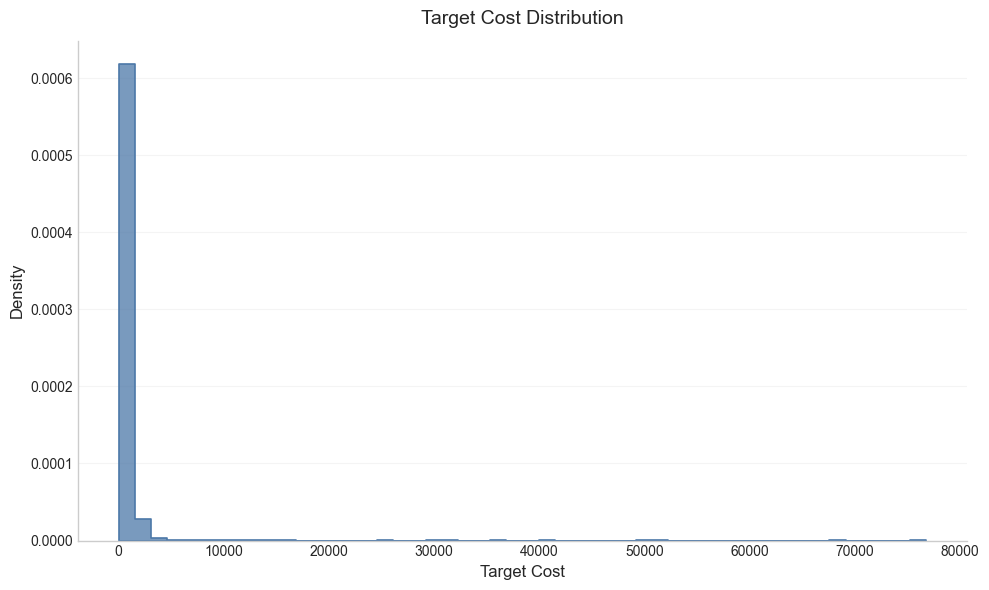

In [41]:
#'target_cost'

plt.style.use("seaborn-v0_8-whitegrid")

plot_data = df[["target_cost"]]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="target_cost",
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
    color="#4C78A8",
    linewidth=1.2
)

plt.title("Target Cost Distribution", fontsize=14, pad=12)
plt.xlabel("Target Cost", fontsize=12)
plt.ylabel("Density", fontsize=12)

# cleaner look wie bei deinen anderen plots
plt.grid(axis="y", alpha=0.2)
plt.grid(axis="x", visible=False)

sns.despine()
plt.tight_layout()
plt.show()

In [23]:
df["target_cost_log"] = np.log1p(df["target_cost"])                  # highly skewed (but plausible), therefore log


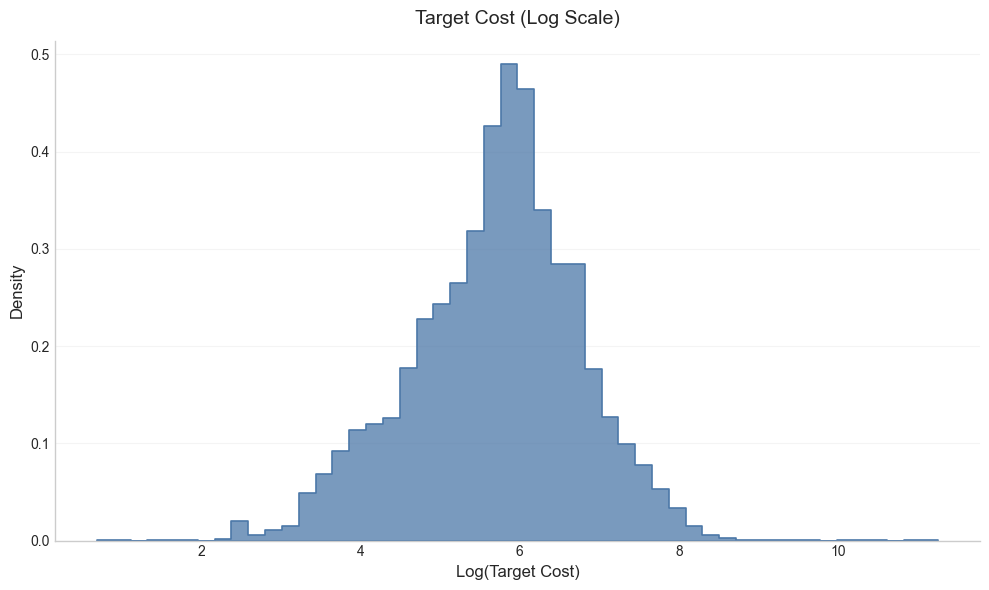

In [51]:
#'"target_cost_log"'

plt.style.use("seaborn-v0_8-whitegrid")

plot_data = df[["target_cost_log"]]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="target_cost_log",
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
    color="#4C78A8",
    linewidth=1.2
)

plt.title("Target Cost (Log Scale)", fontsize=14, pad=12)
plt.xlabel("Log(Target Cost)", fontsize=12)
plt.ylabel("Density", fontsize=12)

# clean grid wie bei deinen anderen plots
plt.grid(axis="y", alpha=0.2)
plt.grid(axis="x", visible=False)

sns.despine()
plt.tight_layout()
plt.show()

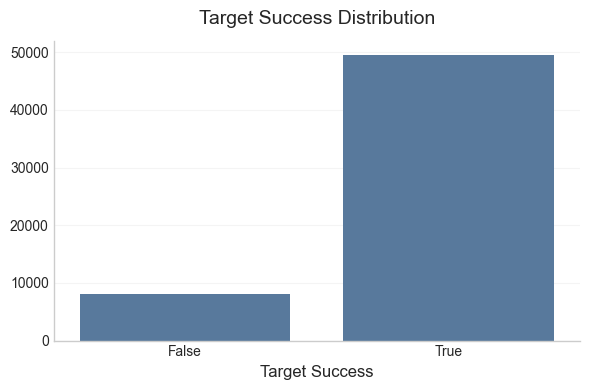

In [49]:
# 'target_success'

plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="target_success",
    color="#4C78A8"
)

plt.title("Target Success Distribution", fontsize=14, pad=12)
plt.xlabel("Target Success", fontsize=12)
plt.ylabel("", fontsize=12)

plt.grid(axis="y", alpha=0.2)
plt.grid(axis="x", visible=False)

sns.despine()
plt.tight_layout()
plt.show()

Results

- remove question_count (not clear enough as feature with counting questionmarks in first response; what about translations or transcripts,etc?)
- orthographic error rate for cleaner text (some other languages are still included; differentiation to translation, code, etc. is complicated)
- target "target_success" needs balancing in the models
- target "target_cost" is highly skewed, therefore "target_cost_log" as new target

In [ ]:
base_path = Path(
    "C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/03_features/conversation_features_target.csv"
)

base_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(base_path, index=False)